# 테슬라 주가 예측 프로그램


In [47]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

In [48]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/TSLA.csv')
data = df['Close'].values.reshape(-1,1)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
# 입력 데이터(X)와 정답 데이터(y)를 만드는 함수
def make_sample(dataset, window):
    train, target = [], []

    # 입력 시퀀스 뒤에 올 정답값이 필요함, 마지막 window 구간은 제외하고 반복
    for i in range(len(dataset) - window):
        # i번째부터 i+window 전까지의 데이터를 입력 시퀀스로 사용
        train.append(dataset[i:(i + window)])
        # 입력 시퀀스 바로 다음 값을 예측 대상 정답으로 사용
        target.append(dataset[i + window])
    # 리스트 형태의 데이터를 numpy 배열로 변환하여 반환
    return np.array(train), np.array(target)

# 하나의 입력 샘플에 사용할 과거 데이터 길이 설정
window = 7

# 모델의 안정적인 학습을 위해 데이터를 0과 1 사이의 값으로 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
# scaler 기준에 맞게 전체 데이터를 정규화
scaled_data = scaler.fit_transform(data)

# 시계열 데이터의 순서 정보 유지를 위해 앞의 80%는 훈련 데이터로 분리
train_size = int(len(scaled_data) * 0.8)

# 앞의 80%를 train_data로 지정
train_data = scaled_data[:train_size]
# 테스트 첫 예측에 필요한 이전 window개 데이터를 포함하여 테스트 데이터 생성
test_data = scaled_data[train_size - window:]

# 학습 데이터 X_train과 정답 Y_train 생성
X_train, Y_train = make_sample(train_data, window)
# 테스트 데이터 X_test와 정답 Y_test 생성
X_test, Y_test = make_sample(test_data, window)

In [50]:
model = Sequential([
    Input(shape=(window, 1)),
    SimpleRNN(64, activation='tanh', return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

In [51]:
history = model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, Y_test),
    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 2.0960e-05 - val_loss: 0.0067
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5715e-06 - val_loss: 0.0054
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4593e-06 - val_loss: 0.0046
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7057e-06 - val_loss: 0.0048
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6019e-06 - val_loss: 0.0038
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.1293e-06 - val_loss: 0.0034
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9046e-06 - val_loss: 0.0024
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9036e-06 - val_loss: 0.0025
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6560e-06 - val_loss: 0.0022
Epoch 10/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0829e-06 - val_loss: 0.0017
Epoch 11/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7760e-06 - val_loss: 0.0020
Epoch 12/100
74/74

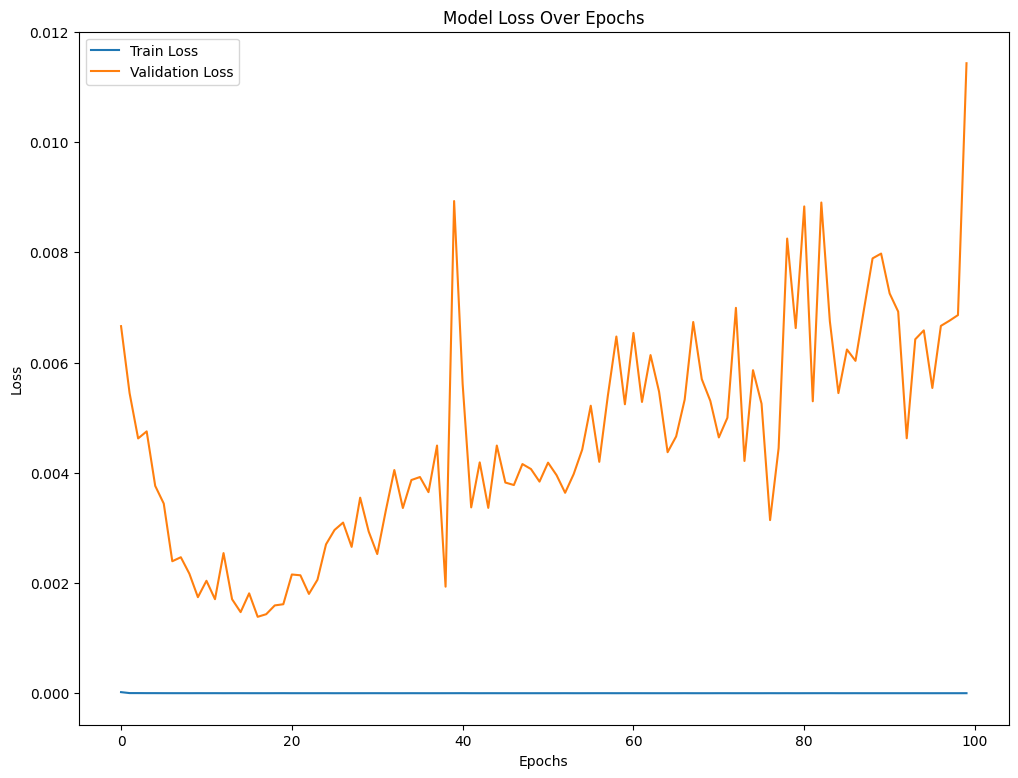

In [52]:
plt.figure(figsize=(12, 9))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


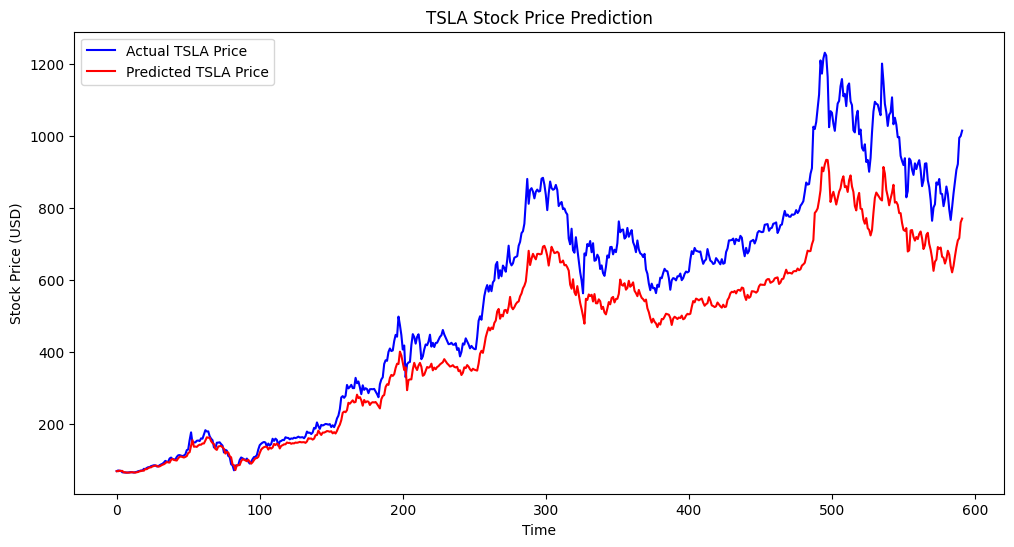

In [53]:
#주가 예측
predictions = model.predict(X_test)
# 예측 값과 정답 값이 정규화된 값이므로 실제 주가 단위로 복원
predictions_inverse = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(Y_test.reshape(-1, 1))

# 실제 주가와 예측 주가 시각화 비교
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual TSLA Price', color='blue')
plt.plot(predictions_inverse, label='Predicted TSLA Price', color='red')
plt.title('TSLA Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()